# **Heart Disease Prediction Using a Hybrid Feature Selection and Ensemble Learning Approach**<br>

## [Kelompok 5] Project Data Science KOM

Anggota Kelompok:<br>
Mikail Achmad (24/542370/PA/23026)<br>
Marco Christian	(24/539714/PA/22915)<br>
Thufail Bahir Al Bariq	(24/537843/PA/22801)<br>
Erdizah Ghodi Al Haidar	(24/537670/PA/22787)<br>

In [57]:
import math
import os
import pandas as pd
import matplotlib as plt
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, ReLU, MaxPooling1D
from tensorflow.keras.layers import Dense, Flatten

In [58]:
PATH = './dataset/heart_disease_cleveland.csv'
df = pd.read_csv(PATH)

## Data Overview

In [59]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [60]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## Preprocessing

## Exploratory Data Analysis

In [62]:
# harmonize target column name to match the paper's 'Num' (0 = no disease, 1 = disease)
target_col = "target" if "target" in df.columns else df.columns[-1]
df = df.rename(columns={target_col: "num"})

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [63]:
def iqr_outlier_removal(data: pd.DataFrame, cols) -> pd.DataFrame:
    out = data.copy()
    mask = pd.Series(True, index=out.index)
    for c in cols:
        q1, q3 = out[c].quantile(0.25), out[c].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask &= out[c].between(lower, upper)
    return out[mask].reset_index(drop=True)


def min_max_normalize(data: pd.DataFrame, cols) -> pd.DataFrame:
    out = data.copy()
    for c in cols:
        lo, hi = out[c].min(), out[c].max()
        out[c] = (out[c] - lo) / (hi - lo) if hi > lo else 0.0
    return out

feature_cols = [c for c in df.columns if c != "num"]
# continuous-valued columns get IQR trimming, as per the paper's intent
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
continuous_cols = [c for c in continuous_cols if c in df.columns]

df_clean = iqr_outlier_removal(df, continuous_cols)
print(f"Instances before IQR removal: {len(df)} -> after: {len(df_clean)}")

df_norm = min_max_normalize(df_clean, feature_cols)

X = df_norm[feature_cols].to_numpy(dtype=float)
y = df_norm["num"].to_numpy(dtype=int)
n_features = X.shape[1]

print(f"Final data matrix: X={X.shape}, y={y.shape}, n_features={n_features}")
feature_cols

Instances before IQR removal: 303 -> after: 284
Final data matrix: X=(284, 13), y=(284,), n_features=13


['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

# Feature Extraction

## 4. Fitness function (wrapper method)

In [64]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [65]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

_fitness_cache = {}
_clf_template = dict(n_estimators=10, max_depth=5, n_jobs=1, random_state=RNG_SEED)
_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG_SEED)


def sigmoid(v):
    return 1 / (1 + np.exp(-v))


def to_binary_mask(vec):
    '''Continuous search vector -> boolean feature mask via sigmoid thresholding.'''
    probs = sigmoid(vec)
    mask = probs > 0.5
    if not mask.any():  # never allow the empty subset
        mask[np.argmax(probs)] = True
    return mask


def objective_value(vec) -> float:
    '''Lower is better (this is what the paper's Fig. 3 plots).'''
    mask = to_binary_mask(vec)
    key = mask.tobytes()
    if key in _fitness_cache:
        return _fitness_cache[key]

    Xs = X[:, mask]
    acc = cross_val_score(
        RandomForestClassifier(**_clf_template), Xs, y, cv=_cv, scoring="accuracy"
    ).mean()

    frac_selected = mask.sum() / len(mask)
    obj = 100.0 * ((1 - acc) + 0.01 * frac_selected)
    _fitness_cache[key] = obj
    return obj


def fitness_from_objective(obj):
    '''Higher is better; used where an algorithm expects a fitness to maximize.'''
    return -obj


## 5. Standalone Genetic Algorithm (paper, Section IV-A-1)

In [66]:

def genetic_algorithm(n_features, pop_size=10, generations=20,
                       crossover_prob=0.9, mutation_prob=0.05, seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    population = local_rng.uniform(-1, 1, size=(pop_size, n_features))
    history = []

    def evaluate(pop):
        return np.array([objective_value(ind) for ind in pop])

    obj_vals = evaluate(population)
    best_idx = obj_vals.argmin()
    best_vec, best_obj = population[best_idx].copy(), obj_vals[best_idx]
    history.append(best_obj)

    for _ in range(generations):
        fitness = fitness_from_objective(obj_vals)
        fitness_shifted = fitness - fitness.min() + 1e-6  # roulette needs positives
        probs = fitness_shifted / fitness_shifted.sum()

        # 1) Selection (roulette wheel)
        parents_idx = local_rng.choice(pop_size, size=pop_size, p=probs)
        parents = population[parents_idx]

        # 2) Crossover (single-point)
        children = parents.copy()
        for i in range(0, pop_size - 1, 2):
            if local_rng.random() < crossover_prob:
                point = local_rng.integers(1, n_features)
                children[i, point:], children[i + 1, point:] = (
                    parents[i + 1, point:].copy(), parents[i, point:].copy(),
                )

        # 3) Mutation
        mut_mask = local_rng.random(children.shape) < mutation_prob
        children[mut_mask] += local_rng.normal(0, 0.5, size=mut_mask.sum())

        # 4) Replacement (elitism: keep the best individual seen so far)
        children[0] = best_vec
        population = children

        obj_vals = evaluate(population)
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < best_obj:
            best_obj, best_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()
        history.append(best_obj)

    return best_vec, best_obj, history


ga_best_vec, ga_best_obj, ga_history = genetic_algorithm(n_features)
print(f"GA best objective: {ga_best_obj:.3f}")
print(f"GA selected features: {[f for f,m in zip(feature_cols, to_binary_mask(ga_best_vec)) if m]}")


GA best objective: 17.243
GA selected features: ['age', 'sex', 'cp', 'trestbps', 'fbs', 'exang', 'slope', 'ca', 'thal']


## 6. Standalone Cuckoo Search Algorithm (paper, Section IV-A-2)

In [67]:

def levy_flight(shape, beta=1.5, rng=rng):
    # Mantegna's algorithm for Levy-distributed steps
    num = math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma_u = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma_u, size=shape)
    v = rng.normal(0, 1, size=shape)
    return u / (np.abs(v) ** (1 / beta))


def cuckoo_search(n_features, n_nests=15, iterations=20, pa=0.25, levy_lambda=1.5,
                   seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    nests = local_rng.uniform(-1, 1, size=(n_nests, n_features))
    obj_vals = np.array([objective_value(n) for n in nests])
    best_idx = obj_vals.argmin()
    best_vec, best_obj = nests[best_idx].copy(), obj_vals[best_idx]
    history = [best_obj]

    for _ in range(iterations):
        # Levy-flight guided new solutions
        step = levy_flight(nests.shape, beta=levy_lambda, rng=local_rng)
        new_nests = nests + 0.01 * step * (nests - best_vec)
        new_obj = np.array([objective_value(n) for n in new_nests])

        improved = new_obj < obj_vals
        nests[improved] = new_nests[improved]
        obj_vals[improved] = new_obj[improved]

        # a fraction pa of the worst nests are abandoned and rebuilt randomly
        n_abandon = int(pa * n_nests)
        worst_idx = np.argsort(obj_vals)[-n_abandon:]
        nests[worst_idx] = local_rng.uniform(-1, 1, size=(n_abandon, n_features))
        obj_vals[worst_idx] = [objective_value(n) for n in nests[worst_idx]]

        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < best_obj:
            best_obj, best_vec = obj_vals[gen_best_idx], nests[gen_best_idx].copy()
        history.append(best_obj)

    return best_vec, best_obj, history


csa_best_vec, csa_best_obj, csa_history = cuckoo_search(n_features)
print(f"CSA best objective: {csa_best_obj:.3f}")
print(f"CSA selected features: {[f for f,m in zip(feature_cols, to_binary_mask(csa_best_vec)) if m]}")


CSA best objective: 17.174
CSA selected features: ['age', 'cp', 'fbs', 'restecg', 'thalach', 'oldpeak', 'ca', 'thal']


## 7. Hybrid GA + CSO (paper, *Algorithm 1*)

In [68]:

def hybrid_ga_cso(n_features, pop_size=15, generations=20, mutation_prob=0.05,
                   random_walk_prob=0.25, crossover_prob=0.9, delta=5,
                   levy_lambda=1.5, seed=RNG_SEED):
    local_rng = np.random.default_rng(seed)
    population = local_rng.uniform(-1, 1, size=(pop_size, n_features))

    obj_vals = np.array([objective_value(ind) for ind in population])
    best_idx = obj_vals.argmin()
    gbest_vec, gbest_obj = population[best_idx].copy(), obj_vals[best_idx]
    history = [gbest_obj]
    stagnant_count = 0

    for _ in range(generations):
        # (3) fitness already computed as obj_vals from previous iteration

        # (4-6) Levy-flight-based update toward the global best, then refresh gbest
        step = levy_flight(population.shape, beta=levy_lambda, rng=local_rng)
        alpha = 0.01
        population = population + alpha * step * (population - gbest_vec)

        obj_vals = np.array([objective_value(ind) for ind in population])
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()

        # (7-11) random-walk step for a random subset of individuals, then repair + re-evaluate
        do_walk = local_rng.random(pop_size) > (1 - random_walk_prob)
        idx_pool = np.arange(pop_size)
        for i in np.where(do_walk)[0]:
            xk, xj = population[local_rng.choice(idx_pool, 2, replace=False)]
            population[i] = population[i] + local_rng.random() * (xk - xj)
        population = np.clip(population, -3, 3)  # "repair the solution"
        obj_vals = np.array([objective_value(ind) for ind in population])

        # (12) update global best again after the random-walk pass
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()
            stagnant_count = 0
        else:
            stagnant_count += 1

        # (13-14) swap mutation if global best hasn't improved for `delta` generations
        if stagnant_count >= delta:
            mut_idx = local_rng.integers(0, pop_size)
            i, j = local_rng.choice(n_features, 2, replace=False)
            population[mut_idx, [i, j]] = population[mut_idx, [j, i]]
            if local_rng.random() < mutation_prob:
                population[mut_idx] += local_rng.normal(0, 0.5, size=n_features)
            stagnant_count = 0

        # (15) final evaluate/update pass for this generation
        obj_vals = np.array([objective_value(ind) for ind in population])
        gen_best_idx = obj_vals.argmin()
        if obj_vals[gen_best_idx] < gbest_obj:
            gbest_obj, gbest_vec = obj_vals[gen_best_idx], population[gen_best_idx].copy()

        history.append(gbest_obj)

    return gbest_vec, gbest_obj, history  # (16) final solution


hybrid_best_vec, hybrid_best_obj, hybrid_history = hybrid_ga_cso(n_features)
print(f"Hybrid GA+CSO best objective: {hybrid_best_obj:.3f}")
print(f"Hybrid selected features: {[f for f,m in zip(feature_cols, to_binary_mask(hybrid_best_vec)) if m]}")


Hybrid GA+CSO best objective: 17.243
Hybrid selected features: ['age', 'sex', 'cp', 'trestbps', 'fbs', 'exang', 'slope', 'ca', 'thal']


## 8. Convergence comparison (reproducing the shape of Figure 3)

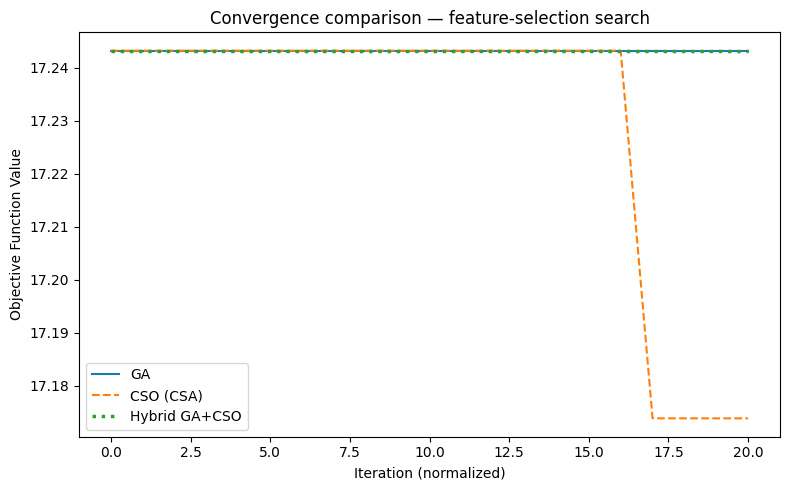

Final objective — GA: 17.243 | CSO: 17.174 | Hybrid GA+CSO: 17.243


In [69]:

def align_length(hist, target_len):
    '''Iteration counts differ (20 vs 100) -- resample onto a common x-axis for plotting.'''
    x_old = np.linspace(0, 1, len(hist))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, hist)


max_len = max(len(ga_history), len(csa_history), len(hybrid_history))

plt.figure(figsize=(8, 5))
plt.plot(align_length(ga_history, max_len), label="GA", linestyle="-")
plt.plot(align_length(csa_history, max_len), label="CSO (CSA)", linestyle="--")
plt.plot(align_length(hybrid_history, max_len), label="Hybrid GA+CSO", linestyle=":", linewidth=2.5)
plt.xlabel("Iteration (normalized)")
plt.ylabel("Objective Function Value")
plt.title("Convergence comparison — feature-selection search")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final objective — GA: {ga_history[-1]:.3f} | CSO: {csa_history[-1]:.3f} | Hybrid GA+CSO: {hybrid_history[-1]:.3f}")


In [70]:

def run_trial(seed):
    _, ga_obj, _ = genetic_algorithm(n_features, seed=seed)
    _, csa_obj, _ = cuckoo_search(n_features, n_nests=15, iterations=20, seed=seed)
    _, hyb_obj, _ = hybrid_ga_cso(n_features, pop_size=15, generations=20, seed=seed)
    return ga_obj, csa_obj, hyb_obj


trials = [run_trial(seed) for seed in range(5)]
trial_df = pd.DataFrame(trials, columns=["GA", "CSA", "Hybrid GA+CSO"])
trial_df.index.name = "seed"
trial_df.loc["mean"] = trial_df.mean()
trial_df.loc["std"] = trial_df.iloc[:-1].std()
trial_df


,GA,CSA,Hybrid GA+CSO
seed,,,
0,17.162604,16.603497,16.603497
1,17.243260,17.952479,17.597869
2,17.085681,15.759095,17.173802
3,16.018118,17.143940,16.839980
4,17.078215,16.731071,17.883022
mean,16.917575,16.838016,17.219634
std,0.507247,0.800956,0.526547


## 9. Selected feature subsets — side by side

In [71]:

def selected_features(vec):
    mask = to_binary_mask(vec)
    return {f: bool(m) for f, m in zip(feature_cols, mask)}

summary = pd.DataFrame({
    "GA": selected_features(ga_best_vec),
    "CSO (CSA)": selected_features(csa_best_vec),
    "Hybrid GA+CSO": selected_features(hybrid_best_vec),
})
summary.loc["n_selected"] = summary.sum()
summary.loc["final_objective"] = [ga_history[-1], csa_history[-1], hybrid_history[-1]]
summary


,GA,CSO (CSA),Hybrid GA+CSO
age,1.00000,1.000000,1.00000
sex,1.00000,0.000000,1.00000
cp,1.00000,1.000000,1.00000
trestbps,1.00000,0.000000,1.00000
chol,0.00000,0.000000,0.00000
fbs,1.00000,1.000000,1.00000
restecg,0.00000,1.000000,0.00000
thalach,0.00000,1.000000,0.00000
exang,1.00000,0.000000,1.00000
oldpeak,0.00000,1.000000,0.00000


## 10. Theoretical complexity (paper, Section VI-C)

In [72]:

# paper's Table 2 values (not this notebook's reduced demo budget)
P_ga, G_ga = 10, 20
n_nests_csa, T_csa = 50, 100
P_hybrid, G_hybrid = 50, 100

print(f"GA complexity term:          P*G       = {P_ga * G_ga}")
print(f"CSA complexity term:         n*T       = {n_nests_csa * T_csa}")
print(f"Hybrid GA+CSO complexity:    P*G + n*I = {P_hybrid * G_hybrid} (dominant term)")
print(f"\nNumber of features in this dataset (n): {n_features}")


GA complexity term:          P*G       = 200
CSA complexity term:         n*T       = 5000
Hybrid GA+CSO complexity:    P*G + n*I = 5000 (dominant term)

Number of features in this dataset (n): 13


# Modeling

#### Random Forest

In [73]:
# rf = RandomForestClassifier(
#     n_estimators=194,
#     max_depth=43,
#     random_state=42
# )

# rf.fit(X_train, y_train)

#### CNN

In [74]:
# cnn = Sequential([
#     Conv1D(
#         filters=34,
#         kernel_size=2,
#         activation='relu',
#         input_shape=(X_train.shape[1], 1)
#     ),

#     MaxPooling1D(pool_size=2),

#     Flatten(),

#     Dense(50, activation='relu'),

#     Dense(1, activation='sigmoid')
# ])

# cnn.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

In [75]:
# X_train_cnn = X_train.reshape(
#     X_train.shape[0],
#     X_train.shape[1],
#     1
# )

In [76]:
# cnn.fit(
#     X_train_cnn,
#     y_train,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.2
# )